In [56]:
# All required imports to run this file are stored here
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [57]:
# Read in the relevant csv files, store them as pd dataframes
all_vuln_df = pd.read_csv("../data/checklist_data_cleaned.csv")
covered_vuln_df = pd.read_csv("../data/specific_data_cleaned.csv")

# Display them both to check
display(all_vuln_df)
display(covered_vuln_df)

,Category,Vulnerability
0,STORAGE,MASWE-0001: Insertion of Sensitive Data into Logs
1,STORAGE,MASWE-0002: Sensitive Data Stored With Insuffi...
2,STORAGE,MASWE-0003: Backup Unencrypted
3,STORAGE,MASWE-0004: Sensitive Data Not Excluded From B...
4,STORAGE,MASWE-0006: Sensitive Data Stored Unencrypted ...
...,...,...
112,PRIVACY,MASWE-0112: Inadequate Data Collection Declara...
113,PRIVACY,MASWE-0113: Lack of Proper Data Management Con...
114,PRIVACY,MASWE-0114: Inadequate Data Visibility Controls
115,PRIVACY,MASWE-0115: Inadequate or Ambiguous User Conse...


,App Name,MASVS Category,Vulnerability,MASVS Counterpart
0,Androgoat,Storage,Insecure Data Storage – Shared Prefs - 1,MASWE-0006: Sensitive Data Stored Unencrypted ...
1,Androgoat,Storage,Insecure Data Storage - Shared Prefs - 2,MASWE-0006: Sensitive Data Stored Unencrypted ...
2,Androgoat,Storage,Insecure Data Storage - SQLite,MASWE-0006: Sensitive Data Stored Unencrypted ...
3,Androgoat,Storage,Insecure Data Storage – Temp Files,MASWE-0006: Sensitive Data Stored Unencrypted ...
4,Androgoat,Storage,Insecure Data Storage – SD Card,MASWE-0007: Sensitive Data Stored Unencrypted ...
...,...,...,...,...
158,BugBazaar,Code,Runtime code modification,MASWE-0085: Unsafe Dynamic Code Loading + MASW...
159,BugBazaar,Code,Improper cache handling,MASWE-0082 (Unsafe Handling of Data from Local...
160,BugBazaar,Resilience,Passcode Bypass,MASWE-0008: Missing Device Secure Lock Verific...
161,BugBazaar,Resilience,Debuggable application,MASWE-0067: Debuggable Flag Not Disabled + MAS...


In [58]:
# --- Count coverage frequency ---
coverage_count = (
    covered_vuln_df.groupby("MASVS Counterpart")
    .size()
    .reset_index(name="Coverage Count")
)

In [59]:

# --- Merge to see which ones are covered and how often ---
merged_df = all_vuln_df.merge(
    coverage_count,
    left_on="Vulnerability",
    right_on="MASVS Counterpart",
    how="left"
)

display(merged_df)

,Category,Vulnerability,MASVS Counterpart,Coverage Count
0,STORAGE,MASWE-0001: Insertion of Sensitive Data into Logs,MASWE-0001: Insertion of Sensitive Data into Logs,7.0
1,STORAGE,MASWE-0002: Sensitive Data Stored With Insuffi...,MASWE-0002: Sensitive Data Stored With Insuffi...,1.0
2,STORAGE,MASWE-0003: Backup Unencrypted,NaN,NaN
3,STORAGE,MASWE-0004: Sensitive Data Not Excluded From B...,NaN,NaN
4,STORAGE,MASWE-0006: Sensitive Data Stored Unencrypted ...,MASWE-0006: Sensitive Data Stored Unencrypted ...,11.0
...,...,...,...,...
112,PRIVACY,MASWE-0112: Inadequate Data Collection Declara...,NaN,NaN
113,PRIVACY,MASWE-0113: Lack of Proper Data Management Con...,NaN,NaN
114,PRIVACY,MASWE-0114: Inadequate Data Visibility Controls,NaN,NaN
115,PRIVACY,MASWE-0115: Inadequate or Ambiguous User Conse...,NaN,NaN


In [60]:
# Fill NaN (means no coverage) with 0
merged_df["Coverage Count"] = merged_df["Coverage Count"].fillna(0).astype(int)

# --- Identify uncovered vulnerabilities ---
uncovered = merged_df[merged_df["Coverage Count"] == 0]

# --- Print results ---
print("=== Coverage summary ===")
print(merged_df[["Vulnerability", "Coverage Count"]])

print("\n=== Uncovered vulnerabilities ===")
print(uncovered["Vulnerability"])

=== Coverage summary ===
                                         Vulnerability  Coverage Count
0    MASWE-0001: Insertion of Sensitive Data into Logs               7
1    MASWE-0002: Sensitive Data Stored With Insuffi...               1
2                       MASWE-0003: Backup Unencrypted               0
3    MASWE-0004: Sensitive Data Not Excluded From B...               0
4    MASWE-0006: Sensitive Data Stored Unencrypted ...              11
..                                                 ...             ...
112  MASWE-0112: Inadequate Data Collection Declara...               0
113  MASWE-0113: Lack of Proper Data Management Con...               0
114    MASWE-0114: Inadequate Data Visibility Controls               0
115  MASWE-0115: Inadequate or Ambiguous User Conse...               0
116       MASWE-0117: Inadequate Permission Management               0

[117 rows x 2 columns]

=== Uncovered vulnerabilities ===
2                         MASWE-0003: Backup Unencrypted
3      

In [61]:
# --- Filter only covered vulnerabilities ---
covered_only = merged_df[merged_df["Coverage Count"] > 0]

# --- Sort by coverage count (descending) ---
covered_sorted = covered_only.sort_values(by="Coverage Count", ascending=False)

# --- Display result ---
print("=== Covered vulnerabilities (sorted by coverage count) ===")
print(covered_sorted[["Vulnerability", "Coverage Count"]])
print("There are:", len(covered_sorted[["Vulnerability", "Coverage Count"]]), "covered vulnerabilities.")

=== Covered vulnerabilities (sorted by coverage count) ===
                                         Vulnerability  Coverage Count
64                        MASWE-0066: Insecure Intents              16
4    MASWE-0006: Sensitive Data Stored Unencrypted ...              11
5    MASWE-0007: Sensitive Data Stored Unencrypted ...               7
0    MASWE-0001: Insertion of Sensitive Data into Logs               7
61            MASWE-0063: Insecure Broadcast Receivers               6
56                     MASWE-0058: Insecure Deep Links               6
25   MASWE-0005: API Keys Hardcoded in the App Package               6
62              MASWE-0064: Insecure Content Providers               6
31   MASWE-0033: Authentication or Authorization Pr...               5
69   MASWE-0071: WebViews Loading Content from Untr...               5
51   MASWE-0053: Sensitive Data Leaked via the User...               5
84                           MASWE-0086: SQL Injection               5
86         MASWE-0

In [62]:
# mark which vulnerabilities are covered
merged_df["Is_Covered"] = merged_df["Coverage Count"] > 0

display(merged_df)

# group by Category and count totals and covered ones
summary = merged_df.groupby("Category").agg(
    total_vulnerabilities=("Vulnerability", "count"),
    covered_vulnerabilities=("Is_Covered", "sum")
)

# optionally, add a coverage percentage
summary["coverage_percentage"] = (
    summary["covered_vulnerabilities"] / summary["total_vulnerabilities"] * 100
).round(1)

print(summary)

,Category,Vulnerability,MASVS Counterpart,Coverage Count,Is_Covered
0,STORAGE,MASWE-0001: Insertion of Sensitive Data into Logs,MASWE-0001: Insertion of Sensitive Data into Logs,7,True
1,STORAGE,MASWE-0002: Sensitive Data Stored With Insuffi...,MASWE-0002: Sensitive Data Stored With Insuffi...,1,True
2,STORAGE,MASWE-0003: Backup Unencrypted,NaN,0,False
3,STORAGE,MASWE-0004: Sensitive Data Not Excluded From B...,NaN,0,False
4,STORAGE,MASWE-0006: Sensitive Data Stored Unencrypted ...,MASWE-0006: Sensitive Data Stored Unencrypted ...,11,True
...,...,...,...,...,...
112,PRIVACY,MASWE-0112: Inadequate Data Collection Declara...,NaN,0,False
113,PRIVACY,MASWE-0113: Lack of Proper Data Management Con...,NaN,0,False
114,PRIVACY,MASWE-0114: Inadequate Data Visibility Controls,NaN,0,False
115,PRIVACY,MASWE-0115: Inadequate or Ambiguous User Conse...,NaN,0,False


            total_vulnerabilities  covered_vulnerabilities  \
Category                                                     
AUTH                           20                        2   
CODE                           15                        5   
CRYPTO                         19                        2   
NETWORK                         6                        3   
PLATFORM                       22                       16   
PRIVACY                         9                        0   
RESILIENCE                     20                        6   
STORAGE                         6                        4   

            coverage_percentage  
Category                         
AUTH                       10.0  
CODE                       33.3  
CRYPTO                     10.5  
NETWORK                    50.0  
PLATFORM                   72.7  
PRIVACY                     0.0  
RESILIENCE                 30.0  
STORAGE                    66.7  


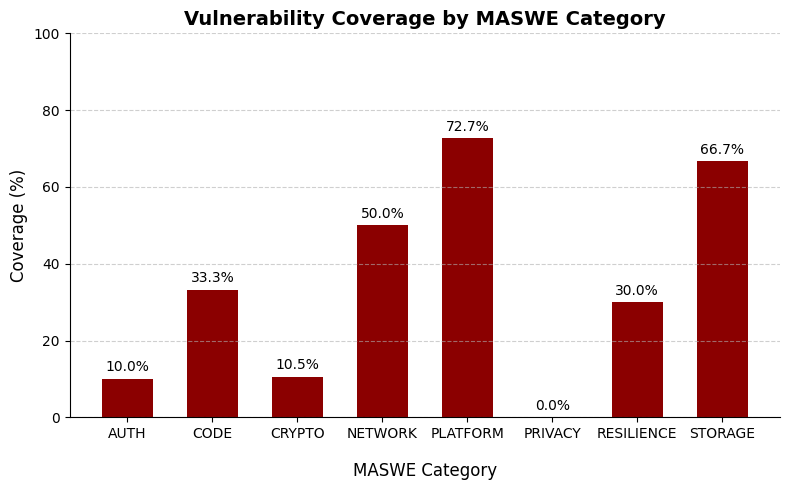

In [63]:

# Explicit style
fig, ax = plt.subplots(figsize=(8, 5))

# Plot the bar chart
ax.bar(summary.index, summary["coverage_percentage"], color="darkred", width=0.6)

# Customize appearance
ax.set_title("Vulnerability Coverage by MASWE Category", fontsize=14, weight='bold')
ax.set_xlabel("MASWE Category", fontsize=12, labelpad=15)
ax.set_ylabel("Coverage (%)", fontsize=12)
ax.set_ylim(0, 100)
ax.grid(axis="y", linestyle="--", alpha=0.6)
ax.spines[["top", "right"]].set_visible(False)

# Add values on top of each bar
for i, v in enumerate(summary["coverage_percentage"]):
    ax.text(i, v + 2, f"{v:.1f}%", ha="center", fontsize=10)

# Show the plot
plt.tight_layout()
plt.show()

# Save the figure
fig.savefig("../plots/vulnerability_coverage_percentage", dpi=300, bbox_inches="tight")

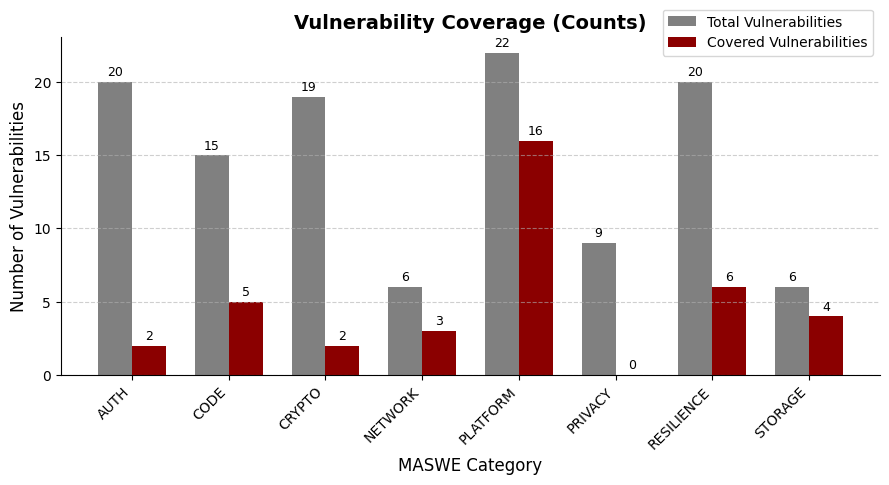

In [64]:
# Prepare data
categories = summary.index
total = summary["total_vulnerabilities"]
covered = summary["covered_vulnerabilities"]

# Set bar positions
x = np.arange(len(categories))
width = 0.35  # width of each bar

# Explicit style plot
fig, ax = plt.subplots(figsize=(9, 5))

# Plot both total and covered bars
bars1 = ax.bar(x - width/2, total, width, label="Total Vulnerabilities", color="gray")
bars2 = ax.bar(x + width/2, covered, width, label="Covered Vulnerabilities", color="darkred")

# Customize plot
ax.set_title("Vulnerability Coverage (Counts)", fontsize=14, weight='bold')
ax.set_xlabel("MASWE Category", fontsize=12)
ax.set_ylabel("Number of Vulnerabilities", fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(categories, rotation=45, ha="right")
ax.legend(
    loc="upper right",          # position relative to the Axes
    bbox_to_anchor=(1, 1.1),  # (x, y) — 1.15 moves it a bit above the top
    frameon=True                # optional: remove box background
)
ax.grid(axis="y", linestyle="--", alpha=0.6)
ax.spines[["top", "right"]].set_visible(False)

# Annotate bars with values
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, height + 0.2,
                f"{int(height)}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()

# Save the figure
fig.savefig("../plots/vulnerability_coverage_counts", dpi=300, bbox_inches="tight")